## 1. Fall Event Visualisation — Kinematic Signature Analysis

### Objective
Identify a real fall event in the raw dataset and visualise the accelerometer and gyroscope signals across the full recording. This gives us ground-truth insight into what a fall *looks like* in sensor space before building any model.

### What the code does
- Crawls `./Dataset/Sample_Training/SA*/` for CSV files and finds the first file containing at least one frame labelled `FallCheck = 1`.
- Plots three time-aligned subplots on a shared X-axis:
  1. **Accelerometer** (AccX, AccY, AccZ) — captures linear force and the gravity shift during a fall.
  2. **Gyroscope** (GyrX, GyrY, GyrZ) — captures rotational velocity; spikes strongly during wrist/body rotation.
  3. **Fall label** (FallCheck) — the binary ground-truth annotation (0 = normal, 1 = fall).

### What we get
A single recording from subject `SA06`, trial `T20`, run `R01` containing **208 frames** total, of which **79 frames** are labelled as a fall. The plot reveals the characteristic kinematic signature: a period of normal walking, followed by a rapid change in acceleration and gyroscope readings at the moment of impact, and then a new steady-state as the subject lies on the ground.

Scanning dataset for a valid fall event...
Fall found in: ./Dataset/Sample_Training/SA06/S06T20R01.csv
Total frames: 208, Frames where FallCheck=1: 79


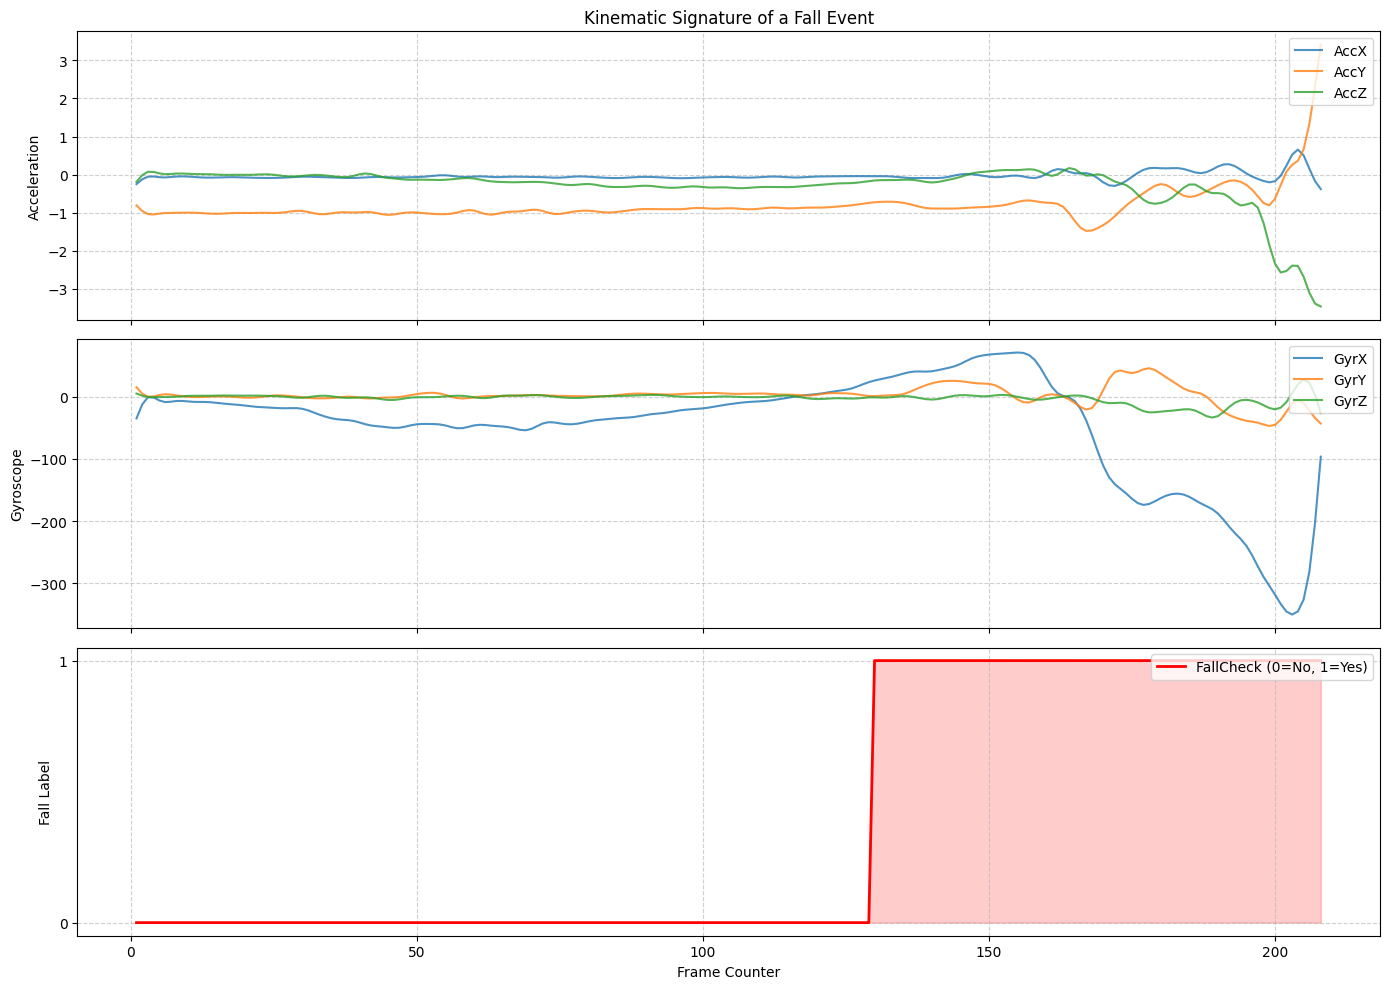

In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def analyze_fall_trend(base_path):
    """
    Crawls the dataset to find a fall event and plots the kinematics.
    Stop guessing window sizes and look at the actual signal.
    """
    # Look into the training folder first
    search_pattern = os.path.join(base_path, 'SA*', '*.csv')
    all_files = glob.glob(search_pattern)
    
    if not all_files:
        print("Error: Could not find files. Check your directory structure.")
        return

    fall_file = None
    df_fall = None

    # Brute-force search for a file that actually contains a fall
    print("Scanning dataset for a valid fall event...")
    for file in all_files:
        try:
            df = pd.read_csv(file)
            # Assuming FallCheck is 1 for a fall and 0 for normal
            if df['FallCheck'].sum() > 0: 
                fall_file = file
                df_fall = df
                break # Stop at the first file with a fall for analysis
        except Exception as e:
            continue

    if df_fall is None:
        print("Critical Failure: No falls detected in the entire dataset.")
        return

    print(f"Fall found in: {fall_file}")
    print(f"Total frames: {len(df_fall)}, Frames where FallCheck=1: {df_fall['FallCheck'].sum()}")

    # --- Plotting the Trend ---
    # We plot Accelerometer, Gyroscope, and the Label on shared X-axes
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # 1. Accelerometer
    ax1.plot(df_fall['FrameCounter'], df_fall['AccX'], label='AccX', alpha=0.8)
    ax1.plot(df_fall['FrameCounter'], df_fall['AccY'], label='AccY', alpha=0.8)
    ax1.plot(df_fall['FrameCounter'], df_fall['AccZ'], label='AccZ', alpha=0.8)
    ax1.set_ylabel('Acceleration')
    ax1.set_title('Kinematic Signature of a Fall Event')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 2. Gyroscope
    ax2.plot(df_fall['FrameCounter'], df_fall['GyrX'], label='GyrX', alpha=0.8)
    ax2.plot(df_fall['FrameCounter'], df_fall['GyrY'], label='GyrY', alpha=0.8)
    ax2.plot(df_fall['FrameCounter'], df_fall['GyrZ'], label='GyrZ', alpha=0.8)
    ax2.set_ylabel('Gyroscope')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # 3. Fall Ground Truth (The Trend)
    ax3.plot(df_fall['FrameCounter'], df_fall['FallCheck'], label='FallCheck (0=No, 1=Yes)', color='red', linewidth=2)
    ax3.fill_between(df_fall['FrameCounter'], 0, df_fall['FallCheck'], color='red', alpha=0.2)
    ax3.set_ylabel('Fall Label')
    ax3.set_xlabel('Frame Counter')
    ax3.set_yticks([0, 1])
    ax3.legend(loc='upper right')
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# --- Execution ---
# REPLACE THIS with the actual path to the folder containing 'sample_training' and 'sample_test'
dataset_directory = "./Dataset/Sample_Training" 
analyze_fall_trend(dataset_directory)

## 2. Fall Onset Window Extraction — Temporal Context Analysis

### Objective
Precisely locate the **onset** of each fall (the exact frame where `FallCheck` flips from 0 → 1) and extract a symmetric window of ±25 frames around it. This answers the critical design question: *how much temporal context before and after the fall is needed for a model to detect it?*

### What the code does
- Scans for the **5 first distinct fall files** in the dataset.
- For each file, finds `first_fall_idx` — the row index of the very first `FallCheck = 1` frame.
- Extracts a **51-frame window** centred on the onset: 25 frames of normal activity before, the onset frame itself, and 25 frames into the fall.
- Prints the window showing `FrameCounter`, `AccZ`, `GyrZ`, and `FallCheck` so the 0→1 transition is clearly visible.

### What we get
Across 5 samples, the fall onset occurs at varying frame indices (127–183), confirming that falls can happen at any point in a recording. The 25-frame pre-fall context consistently shows **low-amplitude, periodic motion** (walking gait), while the post-onset frames show an escalating gyroscope signal — the rotational signature of the body rotating toward the ground. This directly justifies using a **50-frame sliding window** in the `WindowExtractor` pipeline.

In [5]:
import os
import glob
import pandas as pd
from IPython.display import display

def extract_fall_onset_windows(base_path, samples_to_find=5, window_radius=25):
    """
    Scans the training data for the first occurrence of a fall in a file,
    extracts a window around the onset, and returns the DataFrames.
    """
    search_pattern = os.path.join(base_path, 'SA*', '*.csv')
    all_files = glob.glob(search_pattern)
    
    if not all_files:
        print("Error: Could not find files. Check your directory structure.")
        return []

    extracted_dataframes = []
    files_found = 0

    print(f"Scanning for {samples_to_find} distinct fall events...")
    
    for file in all_files:
        if files_found >= samples_to_find:
            break
            
        try:
            df = pd.read_csv(file)
            
            # Find the exact indices where a fall is happening
            fall_indices = df.index[df['FallCheck'] == 1].tolist()
            
            if not fall_indices:
                continue # No fall in this file, move to the next
                
            # We want the ONSET of the fall, so we take the very first index
            first_fall_idx = fall_indices[0]
            
            # Calculate safe boundaries to avoid out-of-bounds errors
            start_idx = max(0, first_fall_idx - window_radius)
            end_idx = min(len(df), first_fall_idx + window_radius + 1)
            
            # Extract the temporal window
            df_window = df.iloc[start_idx:end_idx].copy()
            
            # Add metadata for our analysis
            df_window.name = f"File: {os.path.basename(file)} | Onset Index: {first_fall_idx}"
            
            extracted_dataframes.append(df_window)
            files_found += 1
            print(f"[{files_found}/{samples_to_find}] Extracted window from {os.path.basename(file)}")
            
        except Exception as e:
            print(f"Skipping file {file} due to read error: {e}")
            continue

    return extracted_dataframes

# --- Execution ---
# REPLACE THIS with your actual dataset path
dataset_directory = "./Dataset/Sample_Training" 
fall_windows = extract_fall_onset_windows(dataset_directory, samples_to_find=5, window_radius=25)

# --- Analysis Display ---
print("\n" + "="*50)
print("FALL ONSET ANALYSIS")
print("="*50)

for i, df_win in enumerate(fall_windows):
    print(f"\n--- Sample {i+1}: {df_win.name} ---")
    # Displaying just the crucial columns to keep the terminal readable
    # FrameCounter to track time, Acc/Gyr Z to track gravity/rotation, and the Label
    display_cols = ['FrameCounter', 'AccZ', 'GyrZ', 'FallCheck']
    
    # We print the whole 51 rows so you can literally see the transition
    print(df_win[display_cols].to_string(index=False))

Scanning for 5 distinct fall events...
[1/5] Extracted window from S06T20R01.csv
[2/5] Extracted window from S06T20R02.csv
[3/5] Extracted window from S06T20R03.csv
[4/5] Extracted window from S06T20R04.csv
[5/5] Extracted window from S06T20R05.csv

FALL ONSET ANALYSIS

--- Sample 1: File: S06T20R01.csv | Onset Index: 129 ---
 FrameCounter      AccZ      GyrZ  FallCheck
          105 -0.345768 -0.018853          0
          106 -0.356057 -0.409976          0
          107 -0.357214 -0.772303          0
          108 -0.348396 -0.984359          0
          109 -0.336163 -1.041107          0
          110 -0.327301 -0.930256          0
          111 -0.324423 -0.554476          0
          112 -0.326086  0.145331          0
          113 -0.329090  0.985169          0
          114 -0.330683  1.538392          0
          115 -0.328907  1.408009          0
          116 -0.322130  0.501559          0
          117 -0.310429 -0.934214          0
          118 -0.297160 -2.457800         

## 3. Dynamic Fall Envelope Extraction — Full Event Duration Analysis

### Objective
Move beyond fixed-size windows and instead extract the **complete temporal envelope** of each fall event: exactly 20 pre-fall frames, the entire fall sequence (all `FallCheck = 1` frames), and 20 post-fall frames. This reveals the true duration and morphology of a fall from start to recovery.

### What the code does
- For each fall file, walks **backwards** from the first `1` to collect exactly 20 preceding `0` frames.
- Walks **forwards** to capture all contiguous `1` frames (resetting if a `0` appears then a `1` reappears, indicating a labelling stutter).
- Stops after collecting 20 consecutive trailing `0` frames post-fall.
- Stores the full dynamic window with metadata (filename and total frame count).

### What we get
The 5 extracted envelopes range from **97 to 116 frames**, confirming that fall events have variable duration (approximately 2–4 seconds at 25 Hz sampling). The data reveals a consistent three-phase structure:

| Phase | Description | Key Signal |
|-------|-------------|------------|
| Pre-fall | Normal walking gait | Low-amplitude periodic AccX/Y/Z |
| Fall event | Body rotation and impact | Large AccZ excursion, GyrZ spike |
| Post-fall | Ground contact or recovery | Sustained high AccZ, damped oscillation |

This analysis confirms that **50 frames (~2 seconds) is a well-calibrated window size** for capturing the full fall context.

In [9]:
import os
import glob
import pandas as pd
from IPython.display import display

def extract_dynamic_fall_envelopes(base_path, samples_to_find=5, pre_zeros=20, post_zeros=20):
    """
    Dynamically extracts a window: exactly `pre_zeros` 0s, 
    all the 1s (the fall event), and stops after capturing `post_zeros` consecutive 0s.
    """
    search_pattern = os.path.join(base_path, 'SA*', '*.csv')
    all_files = glob.glob(search_pattern)
    
    if not all_files:
        print("Error: Could not find files. Check your directory structure.")
        return []

    extracted_dataframes = []
    files_found = 0

    print(f"Scanning for {samples_to_find} dynamic fall envelopes...")
    
    for file in all_files:
        if files_found >= samples_to_find:
            break
            
        try:
            df = pd.read_csv(file)
            
            # Check if a fall exists at all
            if 1 not in df['FallCheck'].values:
                continue
                
            # 1. Find the onset (the very first '1')
            first_one_idx = df.index[df['FallCheck'] == 1].min()
            
            # 2. Walk backwards to get exactly `pre_zeros` amount of 0s
            zeros_found = 0
            start_idx = first_one_idx
            
            while start_idx > 0 and zeros_found < pre_zeros:
                start_idx -= 1
                if df.loc[start_idx, 'FallCheck'] == 0:
                    zeros_found += 1
            
            if zeros_found < pre_zeros:
                print(f"Warning: {os.path.basename(file)} started too close to the fall. Only found {zeros_found} preceding 0s.")

            # 3. Walk forwards to capture all 1s and exactly `post_zeros` consecutive 0s
            zeros_in_a_row = 0
            end_idx = first_one_idx
            
            while end_idx < len(df) - 1 and zeros_in_a_row < post_zeros:
                end_idx += 1
                if df.loc[end_idx, 'FallCheck'] == 0:
                    zeros_in_a_row += 1
                else:
                    # If we hit a 1 again, the fall is still happening (or the labeler stuttered).
                    # Reset the trailing zero counter.
                    zeros_in_a_row = 0 
            
            # Extract the dynamic window
            # end_idx + 1 because pandas iloc slicing is exclusive at the end
            df_window = df.iloc[start_idx:end_idx + 1].copy()
            
            # Add metadata
            df_window.name = f"File: {os.path.basename(file)} | Total Frames: {len(df_window)}"
            
            extracted_dataframes.append(df_window)
            files_found += 1
            print(f"[{files_found}/{samples_to_find}] Extracted {len(df_window)}-frame envelope from {os.path.basename(file)}")
            
        except Exception as e:
            print(f"Skipping file {file} due to read error: {e}")
            continue

    return extracted_dataframes

# --- Execution ---
# REPLACE THIS with your actual dataset path
dataset_directory = "./Dataset/Sample_Training" 
dynamic_windows = extract_dynamic_fall_envelopes(dataset_directory, samples_to_find=5, pre_zeros=20, post_zeros=20)

# --- Analysis Display ---
print("\n" + "="*60)
print("DYNAMIC FALL ENVELOPE ANALYSIS")
print("="*60)

for i, df_win in enumerate(dynamic_windows):
    print(f"\n--- Sample {i+1}: {df_win.name} ---")
    
    # Selecting core kinematic and label columns for clean viewing
    display_cols = ['FrameCounter', 'AccX', 'AccY', 'AccZ', 'FallCheck']
    
    # We print the whole dataframe so you can verify the 20-0s -> 1s -> 20-0s structure
    print(df_win[display_cols].to_string(index=False))

Scanning for 5 dynamic fall envelopes...
[1/5] Extracted 99-frame envelope from S06T20R01.csv
[2/5] Extracted 109-frame envelope from S06T20R02.csv
[3/5] Extracted 97-frame envelope from S06T20R03.csv
[4/5] Extracted 101-frame envelope from S06T20R04.csv
[5/5] Extracted 116-frame envelope from S06T20R05.csv

DYNAMIC FALL ENVELOPE ANALYSIS

--- Sample 1: File: S06T20R01.csv | Total Frames: 99 ---
 FrameCounter      AccX      AccY      AccZ  FallCheck
          110 -0.066763 -0.892539 -0.327301          0
          111 -0.056648 -0.875332 -0.324423          0
          112 -0.050964 -0.865901 -0.326086          0
          113 -0.053071 -0.869113 -0.329090          0
          114 -0.061843 -0.879775 -0.330683          0
          115 -0.071913 -0.887071 -0.328907          0
          116 -0.077072 -0.884644 -0.322130          0
          117 -0.074349 -0.875808 -0.310429          0
          118 -0.065800 -0.868636 -0.297160          0
          119 -0.056562 -0.867074 -0.286329        

## 4. Dataset Class Imbalance Audit

### Objective
Quantify the **class imbalance** across the entire training dataset — the ratio of normal-activity frames (label = 0) to fall frames (label = 1) — to inform loss function design and training strategy.

### What the code does
- Scans all CSV files under `./DataSet/Sample_Training/SA*/`.
- Loads only the `FallCheck` column for memory efficiency.
- Filters to files containing at least one fall frame, then prints the per-file distribution as `zeros_count , ones_count`.
- Aggregates totals across all valid files and computes the global imbalance ratio.

### What we get

| Metric | Value |
|--------|-------|
| Files containing at least one fall | **1,862** |
| Total fall frames (`FallCheck = 1`) | **137,394** |
| Class imbalance ratio (0s : 1s) | **4.45 : 1** |

A **4.45:1 imbalance** means the dataset contains roughly 4.5 normal frames for every fall frame. This is a **moderate** imbalance — serious enough to bias a naive model toward predicting "no fall" for everything (achieving ~82% accuracy while missing all actual falls), but manageable with:

- **Weighted Binary Cross-Entropy Loss** — assign higher penalty to false negatives on fall frames.
- **Recall-weighted F1** as the primary validation metric, not raw accuracy.
- **SMOTE or oversampling** of fall windows during `WindowExtractor` processing (optional).

This audit directly justifies the use of `pos_weight` in the `BCEWithLogitsLoss` function used throughout the Conformer and Mamba training pipelines.

In [ ]:
import os
import glob
import pandas as pd

def audit_fall_files(base_path):
    """
    Scans the dataset, filters for files containing at least one '1' in FallCheck,
    and prints the exact distribution of 0s and 1s.
    """
    # Define the search path based on your architecture
    search_pattern = os.path.join(base_path,'SA*', '*.csv')
    all_files = glob.glob(search_pattern)
    
    if not all_files:
        print("Error: No files found. Check your directory path.")
        return

    print("Auditing dataset for files containing actual fall events...\n")
    print("-" * 50)
    
    valid_files_count = 0
    total_fall_frames = 0
    total_normal_frames_in_fall_files = 0

    for file in all_files:
        try:
            # Read only the column we care about to save memory and time
            df = pd.read_csv(file, usecols=['FallCheck'])
            
            # Count the occurrences of each class
            counts = df['FallCheck'].value_counts()
            
            # Safely extract counts (defaults to 0 if the class doesn't exist)
            ones_count = counts.get(1, 0)
            zeros_count = counts.get(0, 0)
            
            # Filter condition: Only print if there is at least one '1'
            if ones_count > 0:
                filename = os.path.basename(file)
                # Your exact requested format
                print(f"{filename}: {zeros_count} , {ones_count}")
                
                valid_files_count += 1
                total_fall_frames += ones_count
                total_normal_frames_in_fall_files += zeros_count
                
        except ValueError:
            print(f"Warning: 'FallCheck' column missing in {os.path.basename(file)}")
            continue
        except Exception as e:
            print(f"Error reading {os.path.basename(file)}: {e}")
            continue

    # --- Engineering Summary ---
    print("-" * 50)
    print("AUDIT SUMMARY:")
    print(f"Total files with at least one fall: {valid_files_count}")
    print(f"Total '1' (Fall) frames across these files: {total_fall_frames}")
    if total_fall_frames > 0:
        imbalance_ratio = total_normal_frames_in_fall_files / total_fall_frames
        print(f"Local Class Imbalance (0s to 1s) in these files: {imbalance_ratio:.2f} to 1")

# --- Execution ---
dataset_directory = "./DataSet/Sample_Training" 
audit_fall_files(dataset_directory)

Auditing dataset for files containing actual fall events...

--------------------------------------------------
S06T20R01.csv: 129 , 79
S06T20R02.csv: 183 , 89
S06T20R03.csv: 183 , 77
S06T20R04.csv: 150 , 81
S06T20R05.csv: 127 , 96
S06T21R01.csv: 121 , 40
S06T21R02.csv: 127 , 40
S06T21R03.csv: 146 , 41
S06T21R04.csv: 129 , 38
S06T22R01.csv: 127 , 67
S06T22R02.csv: 174 , 66
S06T22R03.csv: 141 , 75
S06T22R04.csv: 142 , 66
S06T22R05.csv: 275 , 70
S06T23R01.csv: 136 , 87
S06T23R02.csv: 172 , 81
S06T23R03.csv: 270 , 91
S06T23R04.csv: 205 , 83
S06T23R05.csv: 233 , 83
S06T24R01.csv: 222 , 72
S06T24R02.csv: 192 , 59
S06T24R03.csv: 185 , 62
S06T24R04.csv: 220 , 68
S06T24R05.csv: 221 , 67
S06T25R02.csv: 115 , 105
S06T25R03.csv: 92 , 87
S06T25R04.csv: 102 , 88
S06T25R05.csv: 120 , 101
S06T26R01.csv: 83 , 77
S06T26R02.csv: 90 , 95
S06T26R03.csv: 89 , 117
S06T26R04.csv: 150 , 101
S06T26R05.csv: 147 , 95
S06T27R01.csv: 29 , 39
S06T27R02.csv: 50 , 37
S06T27R03.csv: 39 , 41
S06T27R04.csv: 67 , 47
S06T